### Step 1: Import Libraries and Load Data

We start by importing all necessary libraries for data loading, visualization, preprocessing, and modeling.
Then, we load the concrete dataset and check the first few rows.


In [1]:
import pandas as pd        # data loading, dataframe manipulation
import numpy as np         # numerical operations
import matplotlib.pyplot as plt    # basic plots
import seaborn as sns              # advanced, pretty plots

from sklearn.model_selection import train_test_split       # splitting data
from sklearn.preprocessing import StandardScaler           # feature scaling
from sklearn.linear_model import LinearRegression          # baseline model
from sklearn.ensemble import RandomForestRegressor         # random forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # evaluation metrics
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV            # hyperparameter tuning

from xgboost import XGBRegressor                           # XGBoost model
import warnings
warnings.filterwarnings('ignore')                         # suppress warnings



### Step 2: Explore Dataset Structure

We inspect the dataset’s structure, including data types, number of rows/columns, and missing values.
This helps us understand the initial shape of the data.


In [2]:
df = pd.read_csv('/content/concrete (1).csv')

In [3]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   strength                                         

### Step 3: View Summary Statistics

We display descriptive statistics (mean, std, min, max, quartiles) to get an overview of the distributions and spot any anomalies.


In [5]:
# Summary statistics
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### Step 4: Check for Missing and Duplicate Values

We check for missing or duplicate entries to ensure data quality.


In [6]:
df.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
strength,0


In [7]:
df.duplicated().sum()

np.int64(25)

### Step 5: Visualize Target Variable

We plot the distribution of the target variable (`strength`) to understand its range and skewness.
### Step 6: Visualize Feature Distributions

We plot histograms of all numeric features to explore their distributions and detect potential skewness or outliers.


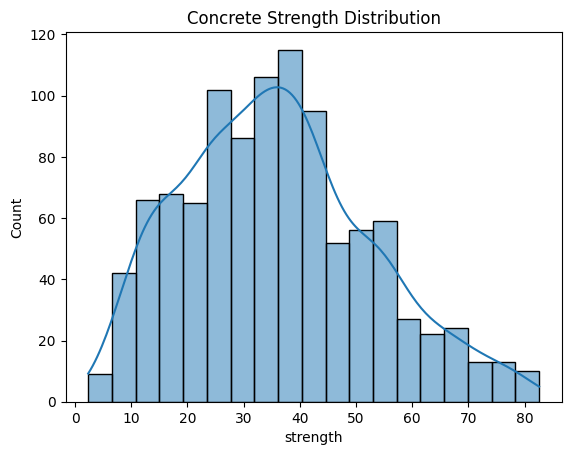

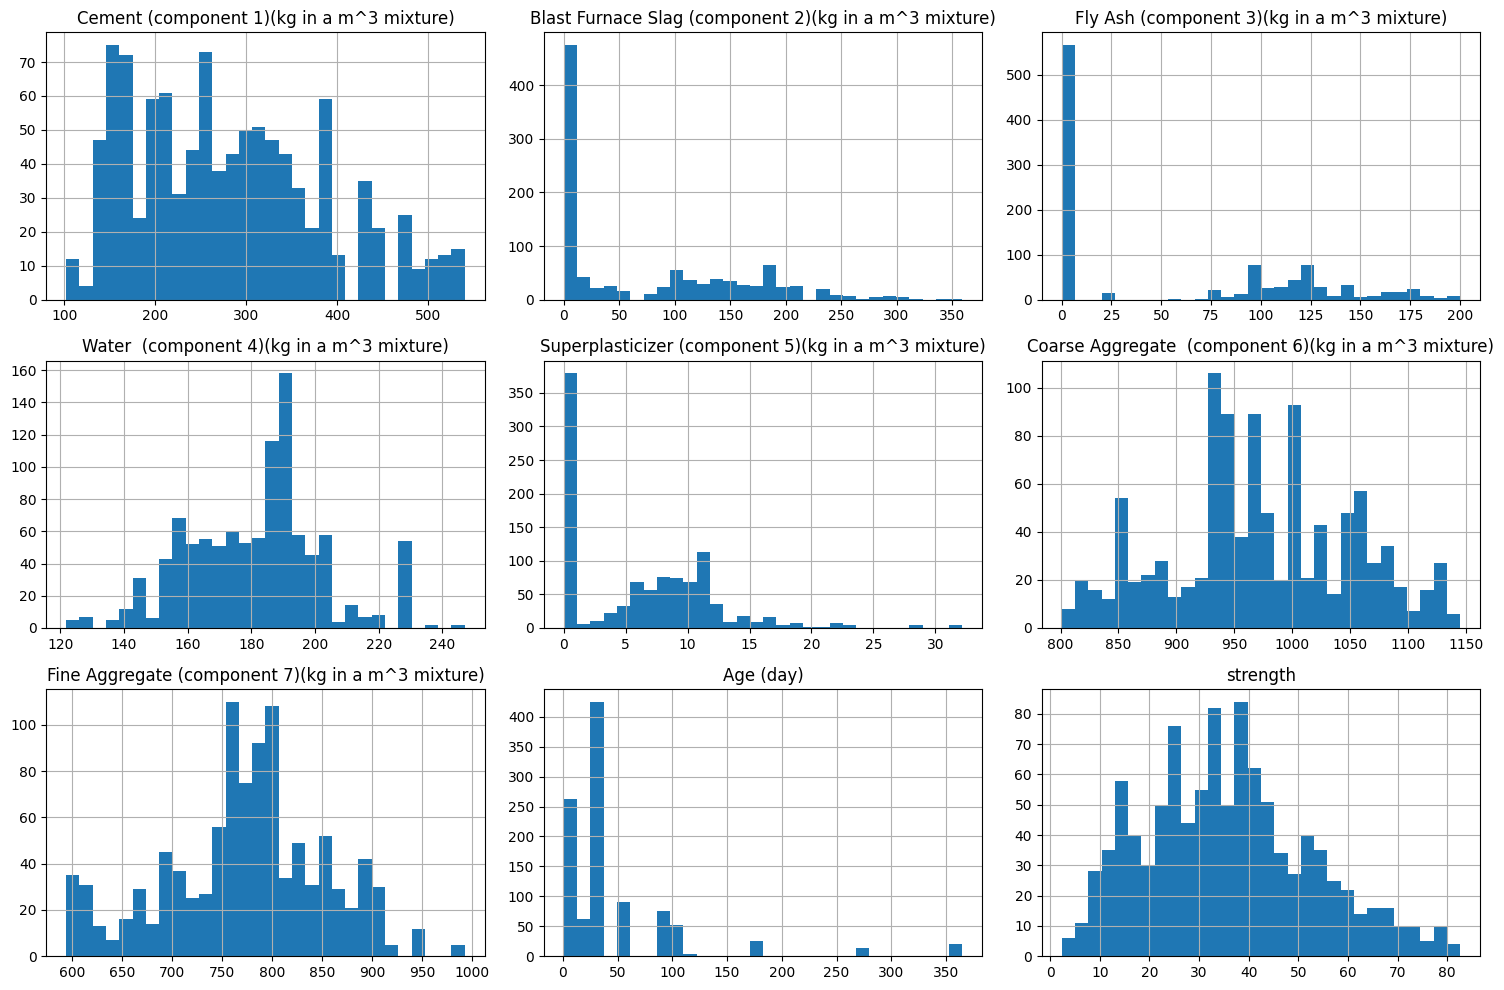

In [8]:
# Target variable
sns.histplot(df['strength'], kde=True)
plt.title('Concrete Strength Distribution')
plt.show()

# All numeric features
df.hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()


### Step 7: Check Feature Correlation

We plot a correlation heatmap to identify relationships between features and the target, helping us spot important predictors.


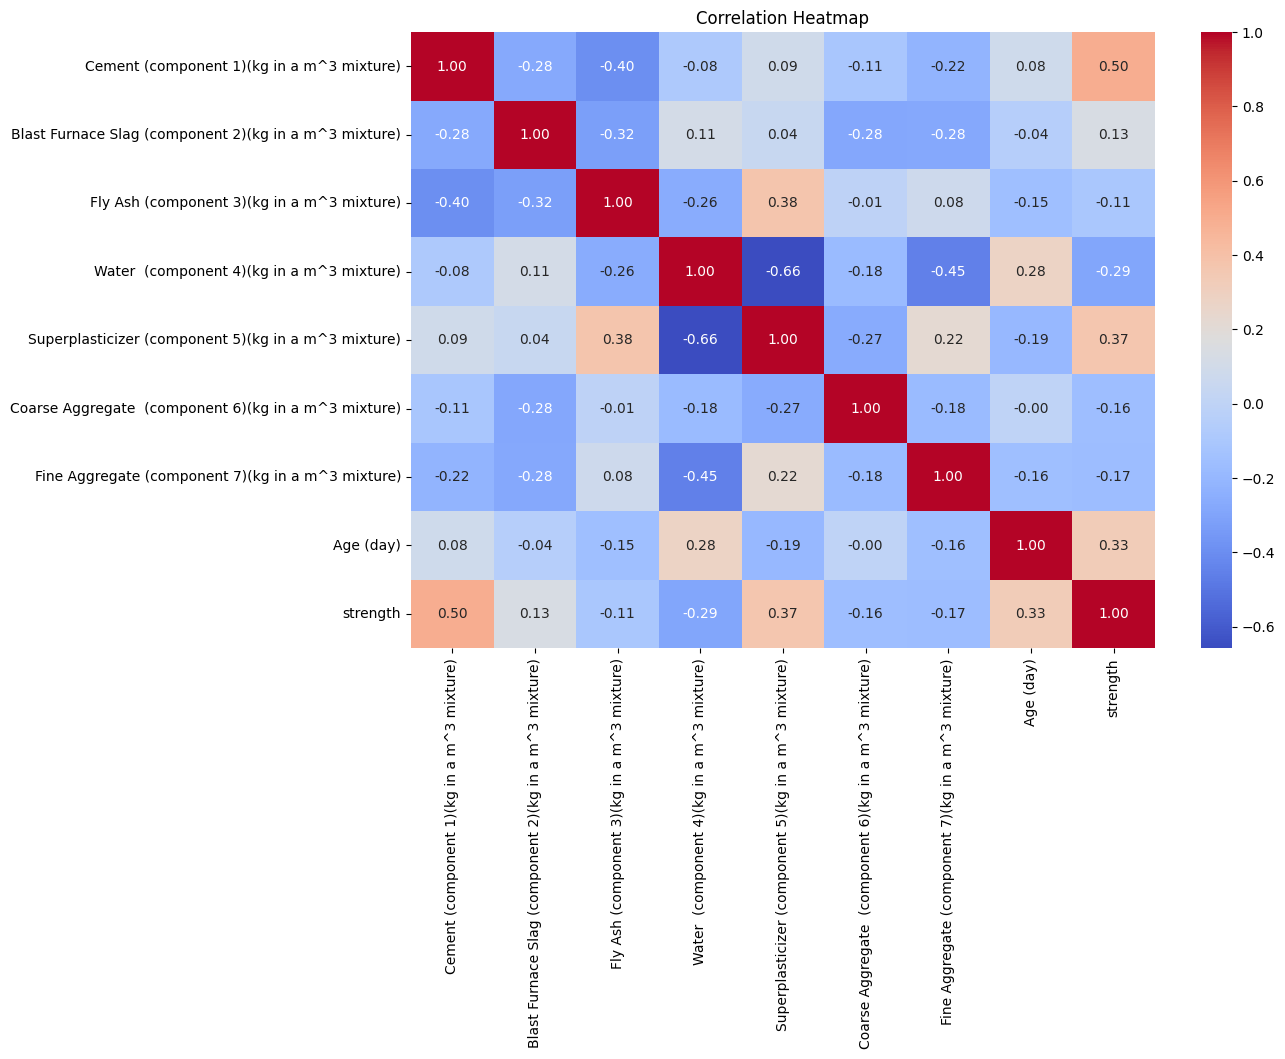

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### Step 8: Identify Outliers Using Boxplots

We generate boxplots for each feature to visually detect outliers.


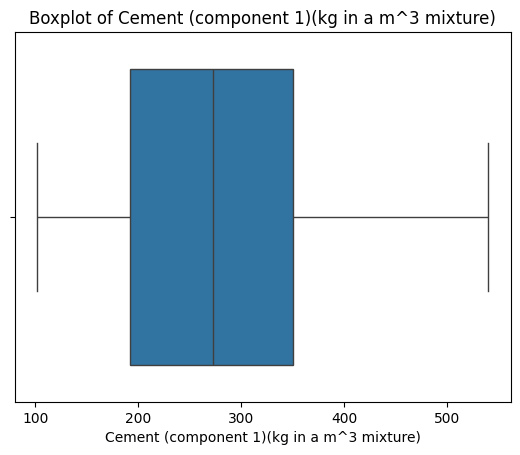

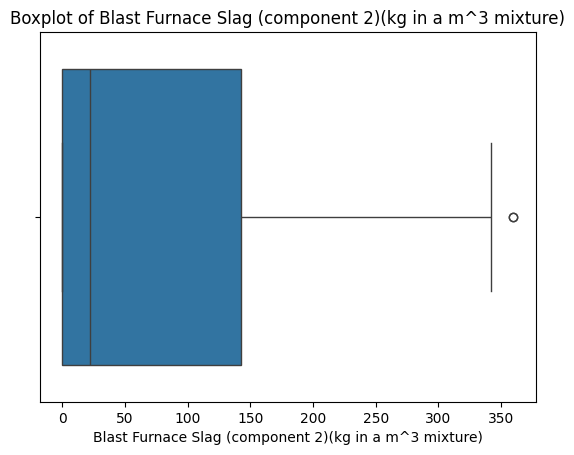

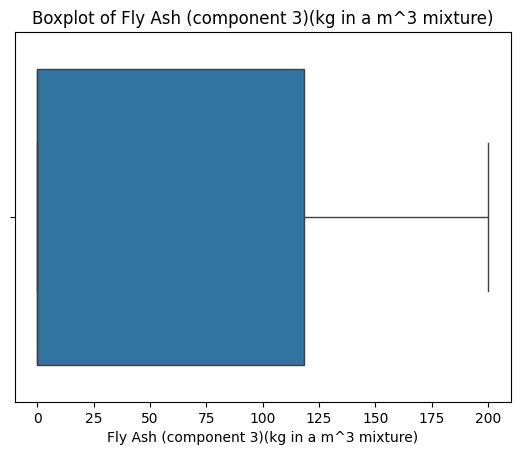

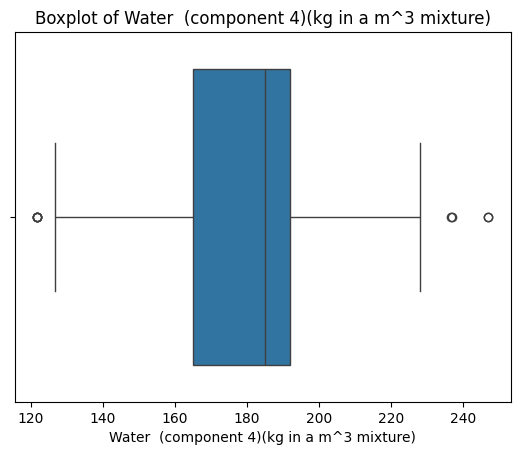

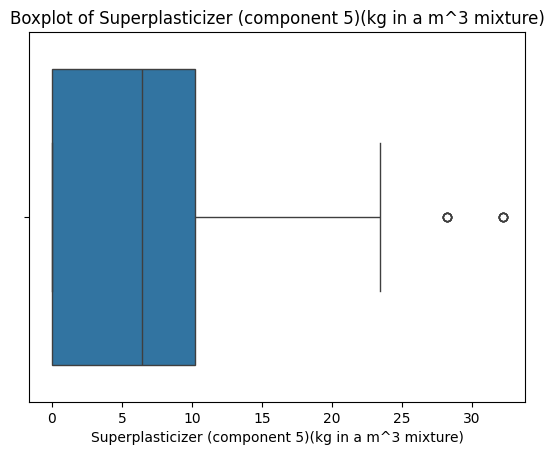

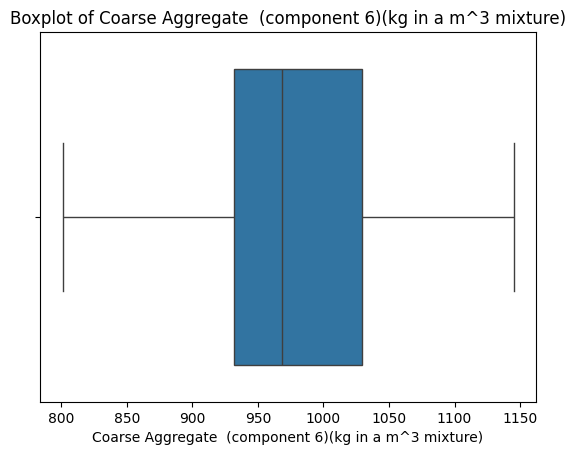

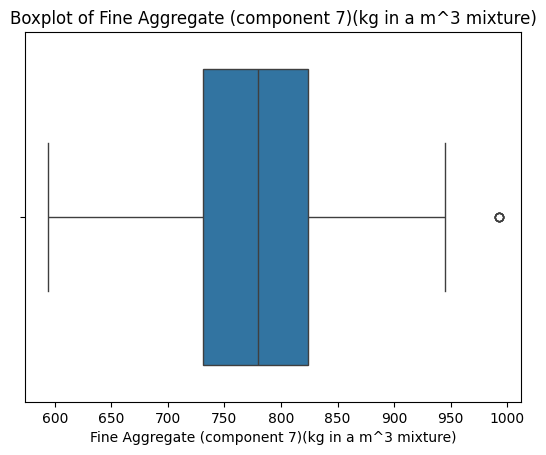

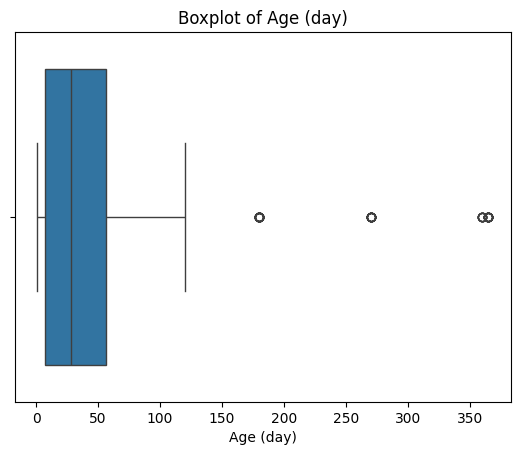

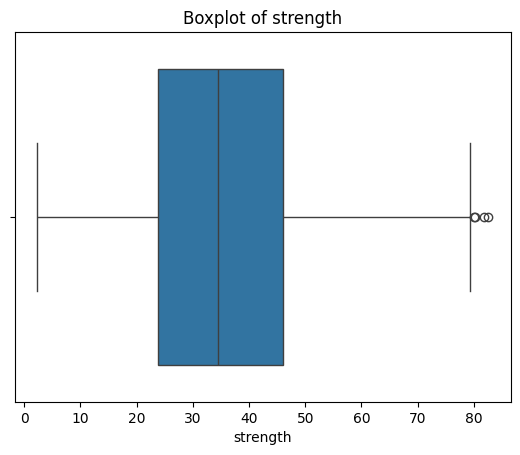

In [10]:
for col in df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


### Step 9: Handle Outliers

We apply the Interquartile Range (IQR) method to cap extreme values and reduce the impact of outliers.


In [11]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


### Step 10: Apply Log Transformation

We apply log transformation to heavily skewed features to improve their distribution and model performance.


In [12]:
for col in ['Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
            'Fly Ash (component 3)(kg in a m^3 mixture)',
            'Superplasticizer (component 5)(kg in a m^3 mixture)',
            'Age (day)']:
    df[col] = np.log1p(df[col])  # log1p handles zero values safely


### Step 11: Scale Features

We standardize features using StandardScaler to ensure all features are on the same scale.


In [13]:
from sklearn.preprocessing import StandardScaler

X = df.drop('strength', axis=1)
y = df['strength']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Step 12: Split Data into Train and Test Sets

We split the dataset into training and testing sets to prepare for model training and evaluation.


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


### Step 13: Train Baseline Models

We train three regression models — Linear Regression, Random Forest, and XGBoost — on the training data.


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initialize models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

# Train models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

### Step 14: Make Predictions

We generate predictions on the test set using all three trained models.


In [16]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)


### Step 15: Evaluate Model Performance

We calculate MAE, MSE, RMSE, and R² to compare model performance and select the best-performing model.


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_test, y_pred, name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f'{name} Performance:')
    print(f'MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}\n')

evaluate_model(y_test, y_pred_lr, 'Linear Regression')
evaluate_model(y_test, y_pred_rf, 'Random Forest')
evaluate_model(y_test, y_pred_xgb, 'XGBoost')


Linear Regression Performance:
MAE: 5.52, MSE: 44.88, RMSE: 6.70, R2: 0.83

Random Forest Performance:
MAE: 3.80, MSE: 30.14, RMSE: 5.49, R2: 0.88

XGBoost Performance:
MAE: 3.17, MSE: 22.47, RMSE: 4.74, R2: 0.91



### Step 16: Visualize Predicted vs Actual

We plot the predicted vs actual values to visually assess model performance.


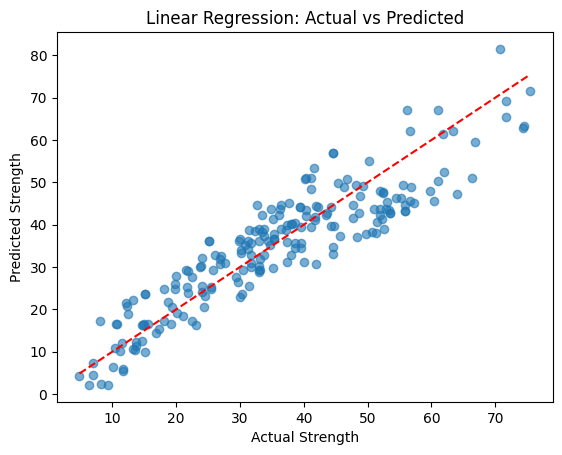

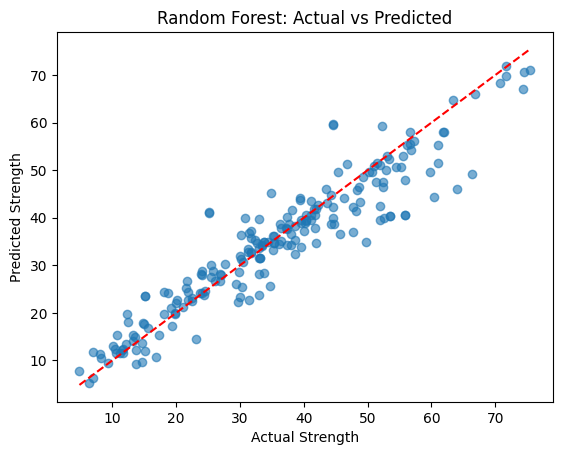

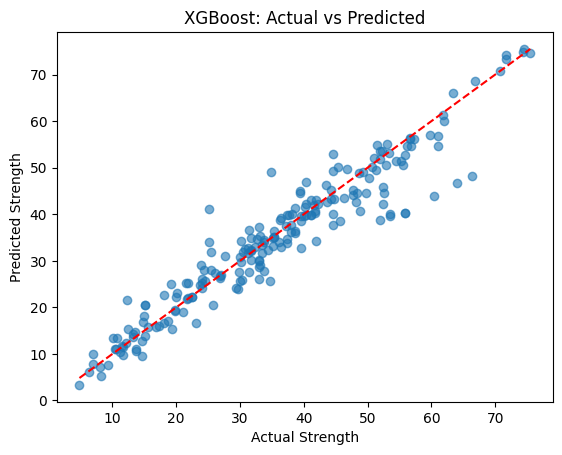

In [18]:
import matplotlib.pyplot as plt

def plot_predicted_vs_actual(y_test, y_pred, title):
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel('Actual Strength')
    plt.ylabel('Predicted Strength')
    plt.title(title)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.show()

plot_predicted_vs_actual(y_test, y_pred_lr, 'Linear Regression: Actual vs Predicted')
plot_predicted_vs_actual(y_test, y_pred_rf, 'Random Forest: Actual vs Predicted')
plot_predicted_vs_actual(y_test, y_pred_xgb, 'XGBoost: Actual vs Predicted')


### Step 17: Plot Residuals

We plot residuals to check for bias or patterns in prediction errors.


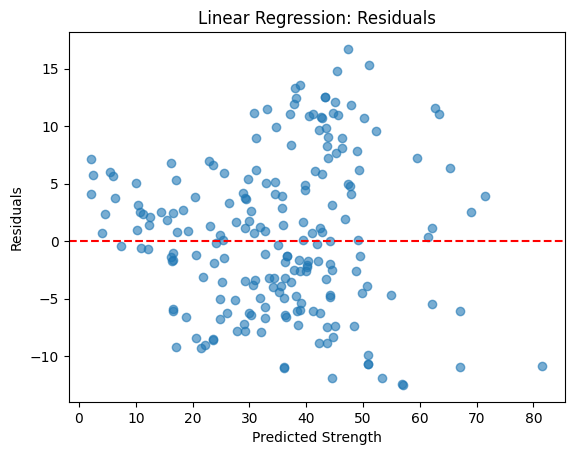

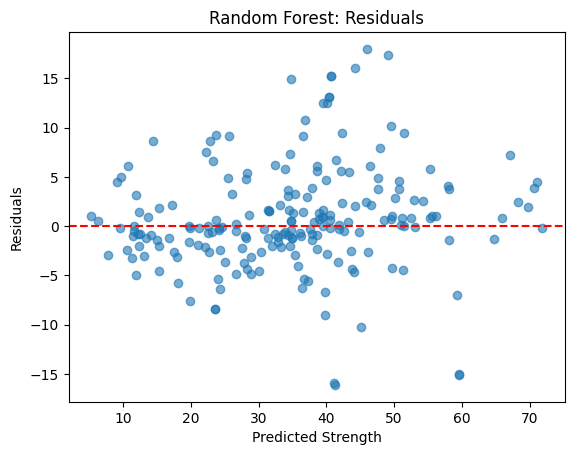

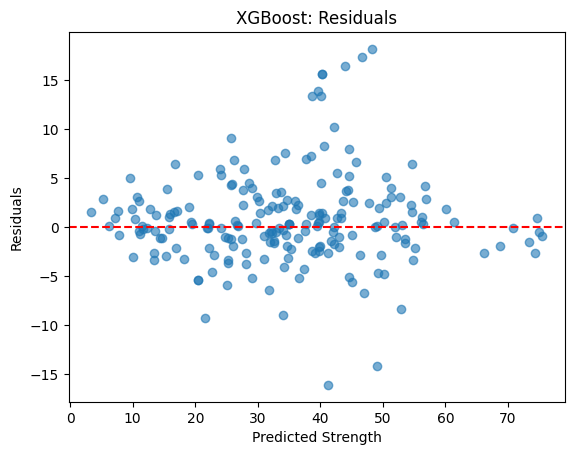

In [19]:
def plot_residuals(y_test, y_pred, title):
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted Strength')
    plt.ylabel('Residuals')
    plt.title(title)
    plt.show()

plot_residuals(y_test, y_pred_lr, 'Linear Regression: Residuals')
plot_residuals(y_test, y_pred_rf, 'Random Forest: Residuals')
plot_residuals(y_test, y_pred_xgb, 'XGBoost: Residuals')


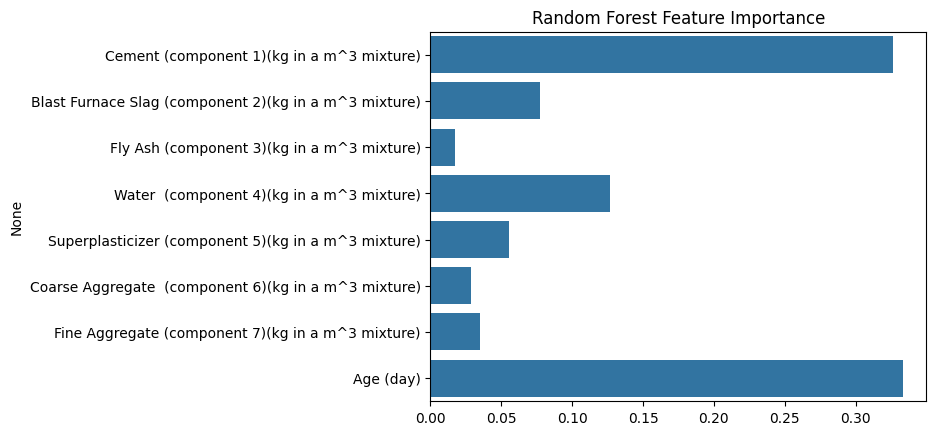

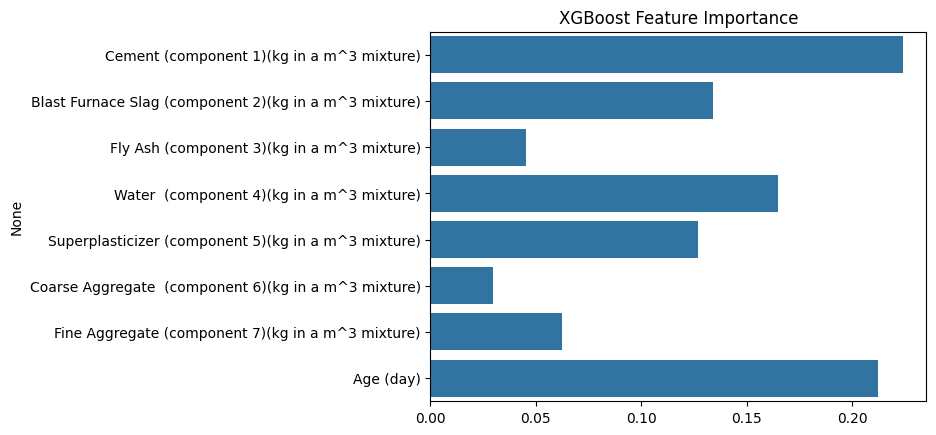

In [20]:
importances_rf = rf.feature_importances_
importances_xgb = xgb.feature_importances_
features = X.columns

# Random Forest
sns.barplot(x=importances_rf, y=features)
plt.title('Random Forest Feature Importance')
plt.show()

# XGBoost
sns.barplot(x=importances_xgb, y=features)
plt.title('XGBoost Feature Importance')
plt.show()


### Step 18: Apply Hyperparameter Tuning to XGBoost

We perform GridSearchCV to optimize hyperparameters for XGBoost and improve model performance.


In [21]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Initialize base model
xgb = XGBRegressor(random_state=42)

# Setup GridSearch
grid_search = GridSearchCV(estimator=xgb,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=3,
                           verbose=1,
                           n_jobs=-1)

# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate tuned model
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

# Final evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_tuned)
mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)

print(f"Tuned XGBoost Performance:\nMAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Tuned XGBoost Performance:
MAE: 2.96, MSE: 19.32, RMSE: 4.40, R2: 0.93


### Step 19: Plot Feature Importance

We visualize feature importance from the tuned XGBoost model to understand which features impact concrete strength the most.


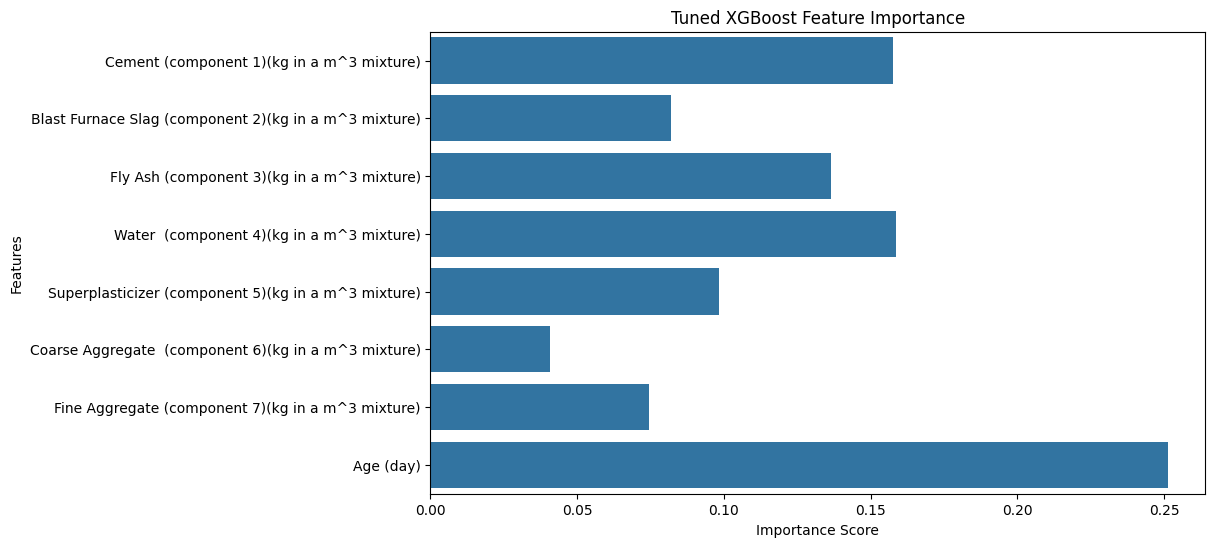

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances_xgb = best_xgb.feature_importances_
features = X.columns

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=importances_xgb, y=features)
plt.title('Tuned XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


### SHAP Explainability Setup

In this step, we import the SHAP library and create an `Explainer` object for our hypertuned XGBoost model.
We use the training data (`X_train`) to initialize the explainer, so SHAP understands the feature relationships.

This will allow us to interpret the model's predictions and understand which features most influence the concrete strength predictions.


### Calculate SHAP Values on Test Set

We now calculate SHAP values on the test set (`X_test`).
These values explain the contribution of each feature to each individual prediction.
This step helps us break down **why** the model made specific predictions.


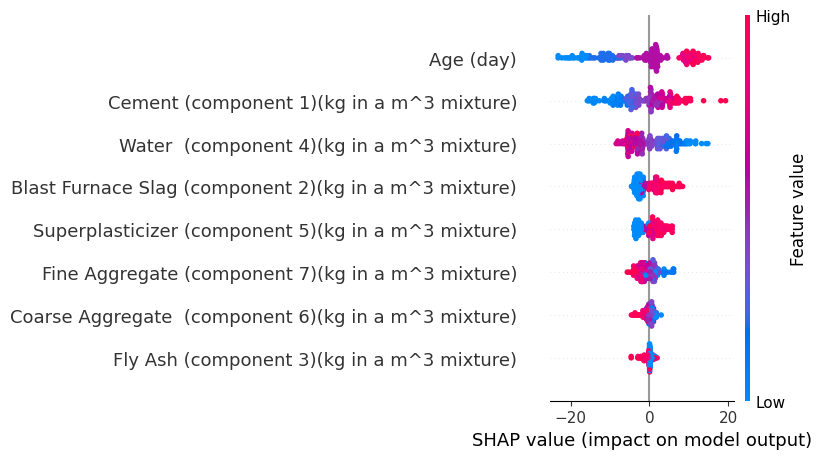

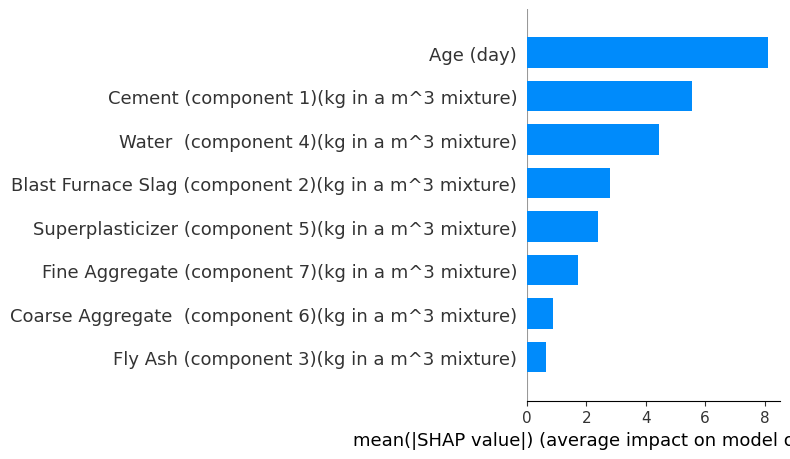

In [23]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_xgb, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_test, feature_names=features)

# Optional: Bar plot summary
shap.summary_plot(shap_values, X_test, plot_type='bar', feature_names=features)




### SHAP Force Plot (Single Test Example)

We generate a **force plot** for the first test sample.
This visualization shows how much each feature pushed the prediction higher or lower compared to the model’s expected average prediction.

- Red bars → features pushing the prediction **up**  
- Blue bars → features pushing the prediction **down**  
- The width of the bars shows the strength of the effect

This gives a local explanation of one prediction.


In [24]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_xgb, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

# Force plot (for the first test sample)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    shap_values.data[0],
    feature_names=features
)
